Повысить устойчивость 0 (НЕТ) 1 (ДА) 0


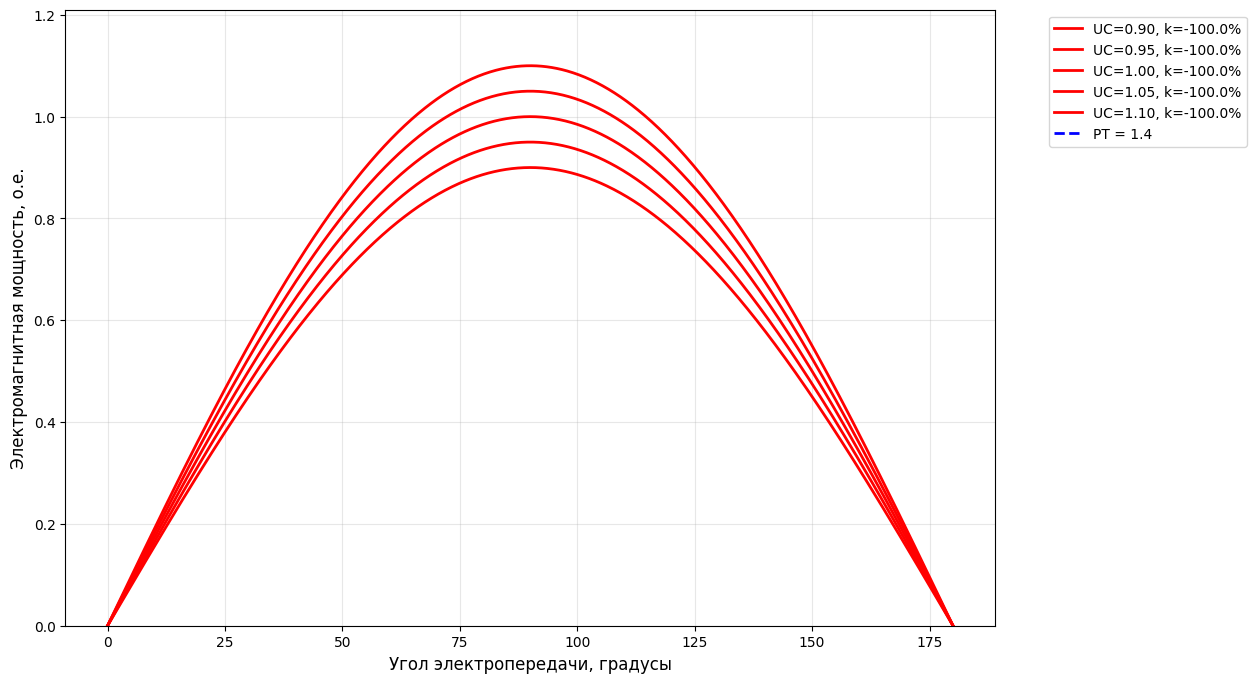

In [8]:
import numpy as np
import matplotlib.pyplot as plt
# Чтение исходных данных из файла
file = open('input_data.txt', 'r')
data = []
line = file.readline()
while line:
    data.append(line)
    line = file.readline()
file.close()
# Извлекаем данные UГ и xсв
UГ = float(data[0].strip())
xсв = float(data[1].strip())
# Повысить Устойчиврсть
otv = int(input('Повысить устойчивость 0 (НЕТ) 1 (ДА) '))
if otv==1:
  otv1 = int(input(' 0 (+ЛЭП) 1 (Увеличичь Uг) '))
  if otv1==1:
    Uг = 1.05
  if otv1==0:
    xсв = xсв/2
# Проверка исходных данных
if UГ < 1.0:
    print("ОШИБКА: Напряжение генератора UГ=", UГ, " ниже допустимого диапазона [1.0, 1.05]")
    exit()
if UГ > 1.05:
    print("ОШИБКА: Напряжение генератора UГ=", UГ, " выше допустимого диапазона [1.0, 1.05]")
    exit()
if xсв < 0.2:
    print("ОШИБКА: Сопротивление связи xсв=", xсв, " ниже допустимого диапазона [0.2, 1.6]")
    exit()
if xсв > 1.6:
    print("ОШИБКА: Сопротивление связи xсв=", xсв, " выше допустимого диапазона [0.2, 1.6]")
    exit()
# Основные параметры
P_Т = 1.4
UС_values = [0.9 + i * 0.05 for i in range(5)]  # Изменено: 0.9, 0.95, 1.0, 1.05, 1.1
delta = np.linspace(0, 180, 1000)  # Изменено: углы от 0 до 180 градусов
# Определение режима работы
if xсв > 1:
    regime = "послеаварийный"
    min_k = 8
else:
    regime = "нормальный"
    min_k = 20
# Анализ статической устойчивости
results = []
for UС in UС_values:
    P_ЭМ_max = (UГ * UС) / xсв
    # Расчет коэффициента запаса
    if P_ЭМ_max <= P_Т:
        k_зап = -100
    else:
        k_зап = ((P_ЭМ_max - P_Т) / P_Т) * 100
    # Определение режима работы
    if k_зап < 0:
        mode = "Невозможен"
        stability = "Недопустим"
    else:
        if k_зап >= min_k:
            mode = regime
            stability = "Допустим"
        else:
            mode = regime
            stability = "Недопустим"

    results.append({
        'UС': UС,
        'P_ЭМ_max': P_ЭМ_max,
        'k_зап': k_зап,
        'mode': mode,
        'stability': stability
    })
# Построение угловых характеристик
plt.figure(figsize=(12, 8))
for UС in UС_values:
    delta_rad = np.radians(delta)
    P_ЭМ_values = (UГ * UС / xсв) * np.sin(delta_rad)
    P_ЭМ_max = (UГ * UС) / xсв
    # Расчет коэффициента запаса
    if P_ЭМ_max <= P_Т:
        k_зап = -100
    else:
        k_зап = ((P_ЭМ_max - P_Т) / P_Т) * 100
    # Выбор цвета линии
    if k_зап >= min_k and k_зап > 0:
        line_color = 'green'
    else:
        line_color = 'red'
    # Создание подписи
        label_text = f'UС={UС:.2f}, k={k_зап:.1f}%'
    plt.plot(delta, P_ЭМ_values, color=line_color, linewidth=2, label=label_text)
# Линия мощности турбины
plt.axhline(y=P_Т, color='blue', linestyle='--', linewidth=2, label=f'PТ = {P_Т}')
plt.xlabel('Угол электропередачи, градусы', fontsize=12)
plt.ylabel('Электромагнитная мощность, о.е.', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# Определение пределов оси Y
max_power = max((UГ * UС) / xсв for UС in UС_values)
plt.ylim(0, max_power * 1.1)
# Сохранение результатов в файл (изменено в соответствии со второй программой)
file = open('results.txt', 'w', encoding='utf-8')
file.write(f'Ug={UГ:.3f}, xсв={xсв:.3f}\n')
file.write(f'Режим: {regime} (мин. k={min_k}%)\n\n')
file.write("Uc\tPmax\tkзап%\tСтатус\n")
for result in results:
    status = "OK" if result['k_зап'] >= min_k and result['k_зап'] > 0 else "НЕ ОК"
    file.write(f"{result['UС']:.2f}\t{result['P_ЭМ_max']:.3f}\t{result['k_зап']:.1f}\t{status}\n")
# Общий вывод (добавлено)
file.write(f'\nВывод: режим {"допустим" if result["k_зап"] > 0 else "не допустим"}')
if result["k_зап"] > 0:
    file.write(f', запас {result["k_зап"]:.1f}% {"достаточен" if result["k_зап"] >= min_k else "недостаточен"}')
file.close()